# Closed-Loop Doppler Pre-Fit Residuals of MEX using IFMS files

This notebook computes pre-fit residuals of MEX using closed-loop Doppler observations of MEX, retrieved from IFMS Level 2 files, as presented in Fig. 4 of the poster.

For a description of the general workflow to obtain pre-fit residuals see the [mro_doppler_prefits.ipynb](mro_doppler_prefits.ipynb) notebook.
The workflow in this notebook deviates from the MRO workflow in the observation model setup (troposphere correction and the Doppler observable model).

## Required Data Files

The following data files are required to run the example.
All data files should be placed in a `data/MEX/` directory relative to this notebook.

### Kernels
All following kernels were retrieved from the [MEX SPICE Data Archive](https://spiftp.esac.esa.int/data/SPICE/MARS-EXPRESS/kernels):
- `fk`:
  - `MEX_V16.TF`
- `sclk`
  - `MEX_260813_STEP.TSC`
- `ck`
  - `ATNM_MEASURED_2015_V04.BC`
- `spk`
  - `ORMM_T19_150101000000_01132.BSP`
  - `MEX_STRUCT_V01.BSP`
  - `NEW_NORCIA.BSP`

These should be placed in `data/MEX/kernels/{kernel-type}/{file-name}`.

### IFMS and Ancillary Files
The IFMS and ancillary files are retrieved from the [ESA Planetary Science Archive](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/). They correspond to all closed loop IFMS Level 2 DP2 X-band data and meteorological Level 1B data in the datasets `MEXMRS_3682` through `MEXMRS_3689`. 

- `ifms`
  - [`M32ICL2L02_D2X_150050821_00.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3682-V1.0/DATA/LEVEL02/CLOSED_LOOP/IFMS/DP2/M32ICL2L02_D2X_150050821_00.TAB)
  - [`M32ICL2L02_D2X_150080523_00.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3683-V1.0/DATA/LEVEL02/CLOSED_LOOP/IFMS/DP2/M32ICL2L02_D2X_150080523_00.TAB)
  - [`M32ICL2L02_D2X_150120705_00.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3684-V1.0/DATA/LEVEL02/CLOSED_LOOP/IFMS/DP2/M32ICL2L02_D2X_150120705_00.TAB)
  - [`M32ICL2L02_D2X_150150550_00.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3685-V1.0/DATA/LEVEL02/CLOSED_LOOP/IFMS/DP2/M32ICL2L02_D2X_150150550_00.TAB)
  - [`M32ICL2L02_D2X_150190654_00.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3686-V1.0/DATA/LEVEL02/CLOSED_LOOP/IFMS/DP2/M32ICL2L02_D2X_150190654_00.TAB)
  - [`M32ICL2L02_D2X_150220453_00.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3687-V1.0/DATA/LEVEL02/CLOSED_LOOP/IFMS/DP2/M32ICL2L02_D2X_150220453_00.TAB)
  - [`M32ICL2L02_D2X_150260726_00.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3688-V1.0/DATA/LEVEL02/CLOSED_LOOP/IFMS/DP2/M32ICL2L02_D2X_150260726_00.TAB)
  - [`M32ICL2L02_D2X_150290435_00.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3689-V1.0/DATA/LEVEL02/CLOSED_LOOP/IFMS/DP2/M32ICL2L02_D2X_150290435_00.TAB)
- `met`
  - [`M32ICL2L1B_MET_150050717_01.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3682-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150050717_02.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3682-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150050717_03.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3682-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150080418_01.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3683-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150080418_02.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3683-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150080418_03.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3683-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150080418_04.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3683-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150120600_01.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3684-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150120600_02.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3684-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150120600_03.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3684-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150120600_04.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3684-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150150445_01.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3685-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150150445_02.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3685-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150150445_03.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3685-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150150445_04.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3685-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150190550_01.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3686-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150190550_02.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3686-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150190550_03.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3686-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150190550_04.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3686-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150220348_01.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3687-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150220348_02.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3687-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150220348_03.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3687-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150220348_04.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3687-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150260621_01.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3688-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150260621_02.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3688-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150260621_03.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3688-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150260621_04.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3688-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150290330_01.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3689-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150290330_02.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3689-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150290330_03.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3689-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)
  - [`M32ICL2L1B_MET_150290330_04.TAB`](https://archives.esac.esa.int/psa/ftp/MARS-EXPRESS/MRS/MEX-M-MRS-1-2-3-EXT5-3689-V1.0/CALIB/CLOSED_LOOP/IFMS/MET/)

These should be placed in `data/MEX/{file-type}/{file-name}`.

In [1]:
from tudatpy.data_input.environment_data import spice

spice.load_standard_kernels()

In [2]:
from pathlib import Path

sc_name = "MEX"
sc_id = 41

mission_file_directory = Path(f"data/{sc_name}")
mission_output_directory = Path(f"output/{sc_name}")


In [3]:
kernels_directory = mission_file_directory / "kernels"

frames_def_kernel = kernels_directory / "fk" / "MEX_V16.TF"
sclk_kernel = kernels_directory / "sclk" / "MEX_260813_STEP.TSC"
orientation_kernels = [kernels_directory / "ck" / "ATNM_MEASURED_2015_V04.BC"]
trajectory_kernels = [
    kernels_directory / "spk" / "ORMM_T19_150101000000_01132.BSP",
    kernels_directory / "spk" / "MEX_STRUCT_V01.BSP",
    kernels_directory / "spk" / "NEW_NORCIA.BSP",
]


# Load frame definition file (required for HGA and spacecraft-fixed frames definition)
spice.load_kernel(frames_def_kernel.as_posix())
# Load SC clock file (required for conversion between SCLK and UTC, used when retrieving SC orientation)
spice.load_kernel(sclk_kernel.as_posix())

# Load orientation kernels
for orientation_file in orientation_kernels:
    spice.load_kernel(orientation_file.as_posix())
# Load trajectory kernels
for trajectory_file in trajectory_kernels:
    spice.load_kernel(trajectory_file.as_posix())


In [4]:
from tudatpy.data_input.tracking_data.ifms import read_ifms_data

ifms_file_directory = mission_file_directory / "ifms"
ifms_file_names = [
    "M32ICL2L02_D2X_150050821_00.TAB",
    "M32ICL2L02_D2X_150080523_00.TAB",
    "M32ICL2L02_D2X_150120705_00.TAB",
    "M32ICL2L02_D2X_150150550_00.TAB",
    "M32ICL2L02_D2X_150190654_00.TAB",
    "M32ICL2L02_D2X_150220453_00.TAB",
    "M32ICL2L02_D2X_150260726_00.TAB",
    "M32ICL2L02_D2X_150290435_00.TAB",
]
ifms_files = [ifms_file_directory / f for f in ifms_file_names]

station_mapping = {"32": "NNOR"}

ground_station_names_per_file = [station_mapping[f.name[1:3]] for f in ifms_files]
tracking_data, tracking_supplementary_data = read_ifms_data(
    [f.as_posix() for f in ifms_files],
    spacecraft_name=sc_name,
    ground_station_names=ground_station_names_per_file,
    frequency_bands=["X-band", "X-band"],
    reception_reference_frequency_band="X-band",
    doppler_reference_frequency=0.0,
    apply_tropospheric_correction=False,
)

In [5]:
# Create default body settings for celestial bodies
from tudatpy.dynamics import environment_setup

bodies_to_create = [
    "Earth",
    "Sun",
    "Mars",
]
global_frame_origin = "SSB"
global_frame_orientation = "ECLIPJ2000"

start_time = min(min(t_data.epochs) for t_data in tracking_data) - 86400
end_time = max(max(t_data.epochs) for t_data in tracking_data) + 86400

body_settings = environment_setup.get_default_body_settings(
    bodies_to_create,
    global_frame_origin,
    global_frame_orientation,
)

# Modify Earth default settings
body_settings.get(
    "Earth"
).rotation_model_settings = environment_setup.rotation_model.gcrs_to_itrs(
    environment_setup.rotation_model.iau_2006,
    global_frame_orientation,
)
# since we defined the Earth rotation model as GCRS to ITRS, we need to set the gravity field reference frame to ITRS as well
body_settings.get("Earth").gravity_field_settings.associated_reference_frame = "ITRS"

body_settings.get(
    "Earth"
).shape_settings = environment_setup.shape.oblate_spherical_spice()

In [6]:
new_norcia_position = spice.get_body_cartesian_position_at_epoch(
    "NEW NORCIA",
    "Earth",
    "EARTH_FIXED",
    aberration_corrections="NONE",
    ephemeris_time=start_time,
)

new_norcia_station = environment_setup.ground_station.basic_station(
    "NNOR", new_norcia_position
)

body_settings.get("Earth").ground_station_settings = [new_norcia_station]

In [7]:
from collections import defaultdict

from tudatpy.math import interpolators

weather_file_names = [
    "M32ICL2L1B_MET_150050717_01.TAB",
    "M32ICL2L1B_MET_150050717_02.TAB",
    "M32ICL2L1B_MET_150050717_03.TAB",
    "M32ICL2L1B_MET_150080418_01.TAB",
    "M32ICL2L1B_MET_150080418_02.TAB",
    "M32ICL2L1B_MET_150080418_03.TAB",
    "M32ICL2L1B_MET_150080418_04.TAB",
    "M32ICL2L1B_MET_150120600_01.TAB",
    "M32ICL2L1B_MET_150120600_02.TAB",
    "M32ICL2L1B_MET_150120600_03.TAB",
    "M32ICL2L1B_MET_150120600_04.TAB",
    "M32ICL2L1B_MET_150150445_01.TAB",
    "M32ICL2L1B_MET_150150445_02.TAB",
    "M32ICL2L1B_MET_150150445_03.TAB",
    "M32ICL2L1B_MET_150150445_04.TAB",
    "M32ICL2L1B_MET_150190550_01.TAB",
    "M32ICL2L1B_MET_150190550_02.TAB",
    "M32ICL2L1B_MET_150190550_03.TAB",
    "M32ICL2L1B_MET_150190550_04.TAB",
    "M32ICL2L1B_MET_150220348_01.TAB",
    "M32ICL2L1B_MET_150220348_02.TAB",
    "M32ICL2L1B_MET_150220348_03.TAB",
    "M32ICL2L1B_MET_150220348_04.TAB",
    "M32ICL2L1B_MET_150260621_01.TAB",
    "M32ICL2L1B_MET_150260621_02.TAB",
    "M32ICL2L1B_MET_150260621_03.TAB",
    "M32ICL2L1B_MET_150260621_04.TAB",
    "M32ICL2L1B_MET_150290330_01.TAB",
    "M32ICL2L1B_MET_150290330_02.TAB",
    "M32ICL2L1B_MET_150290330_03.TAB",
    "M32ICL2L1B_MET_150290330_04.TAB",
]
weather_files = [mission_file_directory / "met" / f for f in weather_file_names]

weather_files_per_station = defaultdict(list)
for file in weather_files:
    station_name = station_mapping[file.name[1:3]]
    weather_files_per_station[station_name].append(file.as_posix())


meteo_interpolator_settings = interpolators.cubic_spline_interpolation(
    boundary_interpolation=interpolators.BoundaryInterpolationType.use_boundary_value
)
for station_name, met_files in weather_files_per_station.items():
    environment_setup.ground_station.set_estrack_weather_data_in_ground_station_settings(
        body_settings.get("Earth").ground_station_settings,
        met_files,
        station_name,
        meteo_interpolator_settings,
    )

In [8]:
from tudatpy.dynamics import environment_setup

body_settings.add_empty_settings(sc_name)

# Retrieve translational ephemeris from SPICE
body_settings.get(
    sc_name
).ephemeris_settings = environment_setup.ephemeris.interpolated_spice(
    start_time,
    end_time,
    10.0,
    global_frame_origin,
    global_frame_orientation,
)

# Retrieve rotational ephemeris from SPICE
body_settings.get(
    sc_name
).rotation_model_settings = environment_setup.rotation_model.spice(
    global_frame_orientation, f"{sc_name}_SPACECRAFT"
)


In [9]:
# Create environment
bodies = environment_setup.create_system_of_bodies(body_settings)

bodies.get(sc_name).system_models.set_default_transponder_turnaround_ratio_function()
bodies.get(
    sc_name
).system_models.transponder_delay = 2.076e-6  # Bertone et al. (2018), Table 1

In [10]:
from tudatpy.estimation import observations

observation_collection = observations.create_observation_collection_from_tracking_data(
    tracking_data, bodies
)
observations.set_tracking_supplementary_data_in_bodies(
    bodies, tracking_supplementary_data
)

In [11]:
compressed_observations = observations.create_compressed_doppler_collection(
    observation_collection,
    60,
    earth_fixed_ground_station_positions={
        "NNOR": bodies.get("Earth")
        .get_ground_station("NNOR")
        .station_state.cartesian_position_at_reference_epoch
    },
)

In [12]:
from tudatpy.estimation import observable_models_setup

hga_ephemeris_settings = environment_setup.ephemeris.interpolated_spice(
    start_time,
    end_time,
    10.0,
    frame_origin=sc_name,
    frame_orientation=f"{sc_name}_SPACECRAFT",
    body_name_to_use=f"{sc_name}_HGA",
)

hga_ephemeris = environment_setup.ephemeris.create_ephemeris(
    hga_ephemeris_settings, f"{sc_name}_HGA"
)

# Set the spacecraft's reference point position to that of the antenna (in the spacecraft-fixed frame)
compressed_observations.set_reference_point(
    bodies,
    hga_ephemeris,
    antenna_name=f"{sc_name}_HGA",
    spacecraft_name=sc_name,
    link_end_type=observable_models_setup.links.LinkEndType.reflector1,
)

In [13]:
from tudatpy.estimation import observable_models_setup, observations_setup

relativistic_lt_correction = observable_models_setup.light_time_corrections.approximated_second_order_relativistic_light_time_correction(
    ["Sun"]
)

tropospheric_lt_correction = observable_models_setup.light_time_corrections.saastamoinen_tropospheric_light_time_correction()

solar_corona_lt_correction = observable_models_setup.light_time_corrections.inverse_power_series_solar_corona_light_time_correction(
    [1.70e12],
    [2.44],
)

doppler_lt_corrections = [
    relativistic_lt_correction,
    tropospheric_lt_correction,
    solar_corona_lt_correction,
]


In [14]:
from tudatpy.estimation.observable_models_setup import model_settings

doppler_link_definitions = compressed_observations.link_definitions_per_observable[
    model_settings.ObservableType.dsn_n_way_averaged_doppler_type
]
observable_model_settings = [
    model_settings.dsn_n_way_doppler_averaged(
        link_definition, doppler_lt_corrections, subtract_doppler_signature=False
    )
    for link_definition in doppler_link_definitions
]

observation_simulators = (
    observations_setup.observations_simulation_settings.create_observation_simulators(
        observable_model_settings, bodies
    )
)

In [15]:
# Compute and set residuals in the compressed observation collection
observations.compute_residuals_and_dependent_variables(
    compressed_observations, observation_simulators, bodies
)


Text(0, 0.5, 'Doppler residuals [Hz]')

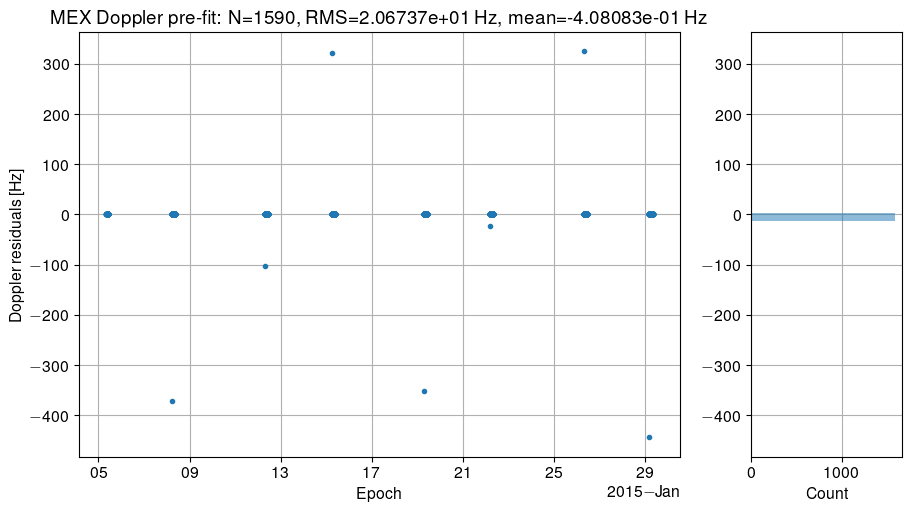

In [16]:
import numpy as np
from matplotlib import pyplot as plt
from tudatpy.astro.time_representation import DateTime

import plotting_utils as plt_utils

prefit_observation_times_dt = [
    DateTime.from_epoch(t).to_python_datetime()
    for t in compressed_observations.get_concatenated_observation_times()
]
prefit_residuals = compressed_observations.get_concatenated_residuals()
prefit_N_obs = len(prefit_residuals)
prefit_RMS = np.sqrt(np.square(prefit_residuals).mean())
prefit_mean = prefit_residuals.mean()


fig, (ax, ax_hist) = plt_utils.create_residual_timeseries_with_histogram_figure()

ax.plot(
    prefit_observation_times_dt,
    prefit_residuals,
    ".",
)
ax_hist.hist(
    prefit_residuals,
    bins=50,
    alpha=0.5,
    orientation="horizontal",
)

ax.set_title(
    f"{sc_name} Doppler pre-fit: N={prefit_N_obs}, RMS={prefit_RMS:.5e} Hz, mean={prefit_mean:.5e} Hz"
)

ax.set_ylabel("Doppler residuals [Hz]")


In [17]:
# create a new observation collection to keep all original observations
filtered_observations = observations.create_new_observation_collection(
    compressed_observations
)

residual_threshold = 0.02  # abs(residuals) > 0.02 Hz
filter_residuals = observations.observations_processing.observation_filter(
    observations.observations_processing.ObservationFilterType.residual_filtering,
    residual_threshold,
)

filtered_observations.filter_observations(filter_residuals)
filtered_observations.remove_empty_observation_sets()


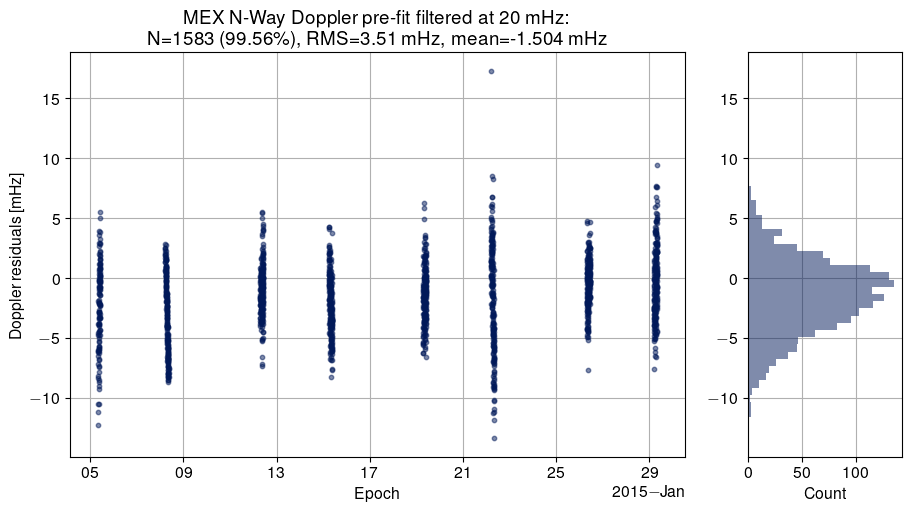

In [18]:
import plotting_utils as plt_utils

with plt.rc_context(
    {
        "axes.prop_cycle": plt_utils.default_residuals_color_cycle(15),
    }
):
    fig, (ax, ax_hist) = (
        plt_utils.plot_doppler_residuals_with_histogram_link_end_grouped(
            filtered_observations, add_legend=False
        )
    )

plt_utils.set_doppler_residual_statistic_title(
    ax,
    residual_threshold,
    filtered_observations,
    compressed_observations,
    mission_name=sc_name,
)
plt_utils.save_figure(
    fig,
    mission_output_directory
    / f"{sc_name}_doppler_prefits_filtered_{residual_threshold:.2f}Hz.png",
)